# CIFAR-100 — Transfer Learning with ResNet-50

Fine-tuning a **pre-trained ResNet-50** (ImageNet weights) on CIFAR-100.

ResNet-50 uses **Bottleneck blocks** (1×1, 3×3, 1×1 convolutions) giving a deeper but efficient
architecture versus ResNet-34’s BasicBlocks. Its final pooling layer outputs **2048 features**
(vs 512 in ResNet-34), providing a richer representation for the classifier head.

**Strategy:**
- Resize CIFAR-100 images 32×32 → 224×224 (ImageNet standard)
- Load `resnet50(weights='DEFAULT')` with ImageNet pre-trained weights
- Replace the final FC layer: `Linear(2048, 100)`
- Fine-tune with SGD (Nesterov) + `CosineAnnealingLR`
- Use `ModelCheckpoint` for crash protection & best model saving


## Imports

In [1]:
import sys
sys.path.append('../..')

import torch
import torch.nn as nn
import torchvision.models as models
from torch import optim
from torch.amp import GradScaler

from utils.dataset import get_cifar100_dataloaders, CIFAR100_CLASSES
from utils.training import fit, test_accuracy
from utils.callbacks import ModelCheckpoint
from utils.plotting import plot_training_curves, show_sample_batch

## Device Setup

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True
print(f'Using device: {device}')

Using device: cuda


## Data Pipeline

ResNet-50 was pre-trained on 224×224 ImageNet images, so we resize CIFAR-100 images
to match. ImageNet normalisation stats are used since the backbone expects them.


In [3]:
batch_size = 64   # Smaller batch for 224×224 inputs
epochs     = 60   # ResNet-50 fine-tuning converges faster than from-scratch

trainloader, valloader, testloader = get_cifar100_dataloaders(
    batch_size=batch_size,
    num_workers=4,
    img_size=224,
    use_imagenet_stats=True,
)
print(f'Train batches: {len(trainloader)} | Val: {len(valloader)} | Test: {len(testloader)}')

C:\Users\asmit\PycharmProjects\CIFAR_10\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train batches: 625 | Val: 157 | Test: 157


## Visualise Sample Batch

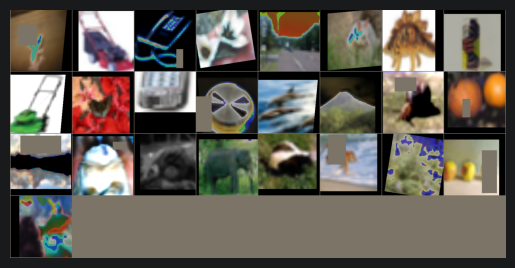

lizard lawn_mower telephone tulip road  possum dinosaur can   lawn_mower butterfly telephone clock dolphin mountain snail orange mountain rabbit chimpanzee elephant skunk tiger forest apple aquarium_fish


In [4]:
show_sample_batch(trainloader, CIFAR100_CLASSES, n=25)

## Model: Pre-trained ResNet-50

Key difference from ResNet-34:
- **Bottleneck blocks**: each block is `Conv1×1 → Conv3×3 → Conv1×1`
- **Final features**: 2048 (vs 512 in ResNet-34)
- **Total params**: ~25.6M


In [5]:
# Load pre-trained ResNet-50
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Replace classifier head: 2048 -> 100 classes
model.fc = nn.Linear(model.fc.in_features, 100)
model = model.to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters    : {total:,}')
print(f'Trainable parameters: {trainable:,}')

# Sanity check
dummy = torch.randn(2, 3, 224, 224, device=device)
print(f'Output shape: {model(dummy).shape}  (expected [2, 100])')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\asmit/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100.0%


Total parameters    : 23,712,932
Trainable parameters: 23,712,932
Output shape: torch.Size([2, 100])  (expected [2, 100])


## Training Setup

- **SGD + Nesterov**: `lr=0.01`, `weight_decay=1e-4`
  (lower LR than from-scratch — weights are already good)
- **CosineAnnealingLR**: smooth decay, no abrupt LR jumps that disturb pretrained features
- **AMP**: float16 for faster 224×224 forward passes on RTX 5070 Ti


In [6]:
criterion = nn.CrossEntropyLoss()
scaler    = GradScaler('cuda')

optimizer = optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9,
    weight_decay=1e-4,
    nesterov=True,
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=epochs, eta_min=1e-6,
)

checkpoint = ModelCheckpoint(
    model,
    checkpoint_path='../../checkpoint/resnet50_cifar100_last.pth',
    best_model_path='../../checkpoint/resnet50_cifar100_best.pth',
    mode='max',
    verbose=True,
)

print(f'Optimizer : SGD (Nesterov), lr=0.01, wd=1e-4')
print(f'Scheduler : CosineAnnealingLR, T_max={epochs}')
print(f'Epochs    : {epochs} | Batch size: {batch_size}')

Optimizer : SGD (Nesterov), lr=0.01, wd=1e-4
Scheduler : CosineAnnealingLR, T_max=60
Epochs    : 60 | Batch size: 64


## Train

In [7]:
train_losses, val_losses, val_accuracies = fit(
    model, trainloader, valloader, criterion,
    optimizer, scheduler, scaler, device, epochs, checkpoint,
    step_scheduler_per_batch=False,  
)

[ModelCheckpoint] New best (max): 74.5500 — saved to ..\checkpoint\resnet50_cifar100_best.pth
Epoch [ 1/60]  Train Loss: 1.6289  Val Loss: 0.8583  Val Acc: 74.55%  LR: 0.009993  Time: 56.97s
[ModelCheckpoint] New best (max): 78.3200 — saved to ..\checkpoint\resnet50_cifar100_best.pth
Epoch [ 2/60]  Train Loss: 0.8547  Val Loss: 0.7273  Val Acc: 78.32%  LR: 0.009973  Time: 44.45s
[ModelCheckpoint] New best (max): 80.3400 — saved to ..\checkpoint\resnet50_cifar100_best.pth
Epoch [ 3/60]  Train Loss: 0.6773  Val Loss: 0.6573  Val Acc: 80.34%  LR: 0.009938  Time: 44.99s
[ModelCheckpoint] New best (max): 80.8200 — saved to ..\checkpoint\resnet50_cifar100_best.pth
Epoch [ 4/60]  Train Loss: 0.5657  Val Loss: 0.6601  Val Acc: 80.82%  LR: 0.009891  Time: 44.80s
[ModelCheckpoint] New best (max): 81.5800 — saved to ..\checkpoint\resnet50_cifar100_best.pth
Epoch [ 5/60]  Train Loss: 0.4836  Val Loss: 0.6447  Val Acc: 81.58%  LR: 0.009830  Time: 45.93s
Epoch [ 6/60]  Train Loss: 0.4178  Val Loss: 

## Training Curves

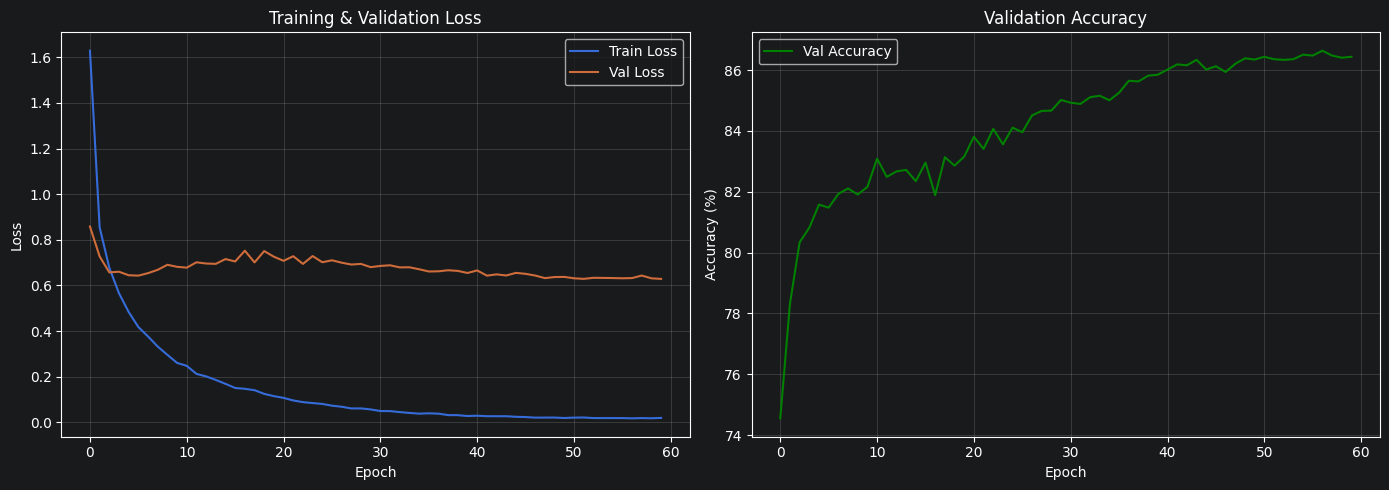

In [8]:
plot_training_curves(train_losses, val_losses, val_accuracies)

## Test Evaluation

Load the best checkpoint and evaluate on the held-out test set.


In [9]:
checkpoint.restore_best_weights()

overall_acc, per_class = test_accuracy(model, testloader, CIFAR100_CLASSES, device)
print(f'Test Accuracy: {overall_acc:.2f}%\n')

print('Per-class accuracies (sorted, best first):')
sorted_classes = sorted(per_class.items(), key=lambda x: x[1], reverse=True)
for cls, acc in sorted_classes:
    bar = '█' * int(acc / 5)
    print(f'  {cls:<20s} {acc:5.1f}%  {bar}')

[ModelCheckpoint] Restored best weights from ..\checkpoint\resnet50_cifar100_best.pth (score=86.6400)
Test Accuracy: 86.52%

Per-class accuracies (sorted, best first):
  sunflower             98.0%  ███████████████████
  keyboard              97.0%  ███████████████████
  orange                97.0%  ███████████████████
  bicycle               96.0%  ███████████████████
  motorcycle            96.0%  ███████████████████
  pickup_truck          96.0%  ███████████████████
  raccoon               96.0%  ███████████████████
  skyscraper            96.0%  ███████████████████
  tank                  96.0%  ███████████████████
  wardrobe              96.0%  ███████████████████
  apple                 95.0%  ███████████████████
  chimpanzee            95.0%  ███████████████████
  lawn_mower            95.0%  ███████████████████
  lion                  95.0%  ███████████████████
  palm_tree             95.0%  ███████████████████
  road                  95.0%  ███████████████████
  skunk         